Setting up Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
from pathlib import Path
import os
from sklearn.metrics import f1_score

In [2]:
def find_metrics_file():
    """Auto-detect where model_metrics.json is located"""
    current = Path.cwd()
    
    # Check common locations
    possible_paths = [
        current / 'model_metrics.json',
        current / 'artifacts' / 'model_metrics.json',
        current.parent / 'artifacts' / 'model_metrics.json',
        current.parent / 'model_metrics.json',
        Path('/workspace/artifacts/model_metrics.json'),  # For cloud environments
    ]
    
    for path in possible_paths:
        if path.exists():
            return path
    
    raise FileNotFoundError("Could not find model_metrics.json")

# Load metrics
metrics_path = find_metrics_file()
with open(metrics_path, 'r') as f:
    metrics = json.load(f)

# Class names (from your confusion matrix order)
# Order: Gestational, No Diabetes, Pre-Diabetes, Type 1, Type 2
class_names = ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']

Setting up the model performance comparison to identify which model is best

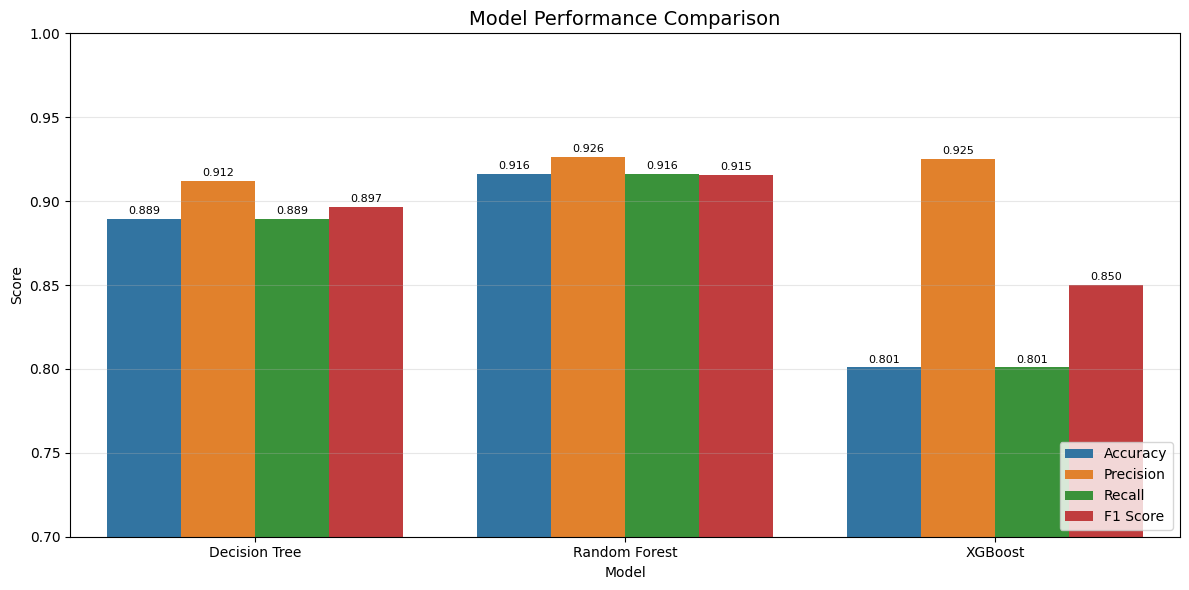

In [3]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        metrics['decision_tree']['accuracy'],
        metrics['random_forest']['accuracy'],
        metrics['xgboost']['accuracy']
    ],
    'Precision': [
        metrics['decision_tree']['precision_weighted'],
        metrics['random_forest']['precision_weighted'],
        metrics['xgboost']['precision_weighted']
    ],
    'Recall': [
        metrics['decision_tree']['recall_weighted'],
        metrics['random_forest']['recall_weighted'],
        metrics['xgboost']['recall_weighted']
    ],
    'F1 Score': [
        metrics['decision_tree']['f1_weighted'],
        metrics['random_forest']['f1_weighted'],
        metrics['xgboost']['f1_weighted']
    ]
})

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df_melted = comparison_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')
sns.barplot(data=comparison_df_melted, x='Model', y='Score', hue='Metric', ax=ax)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_ylim(0.7, 1.0)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('../artifacts/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Confusion Matrix heatmaps per diabetes stage

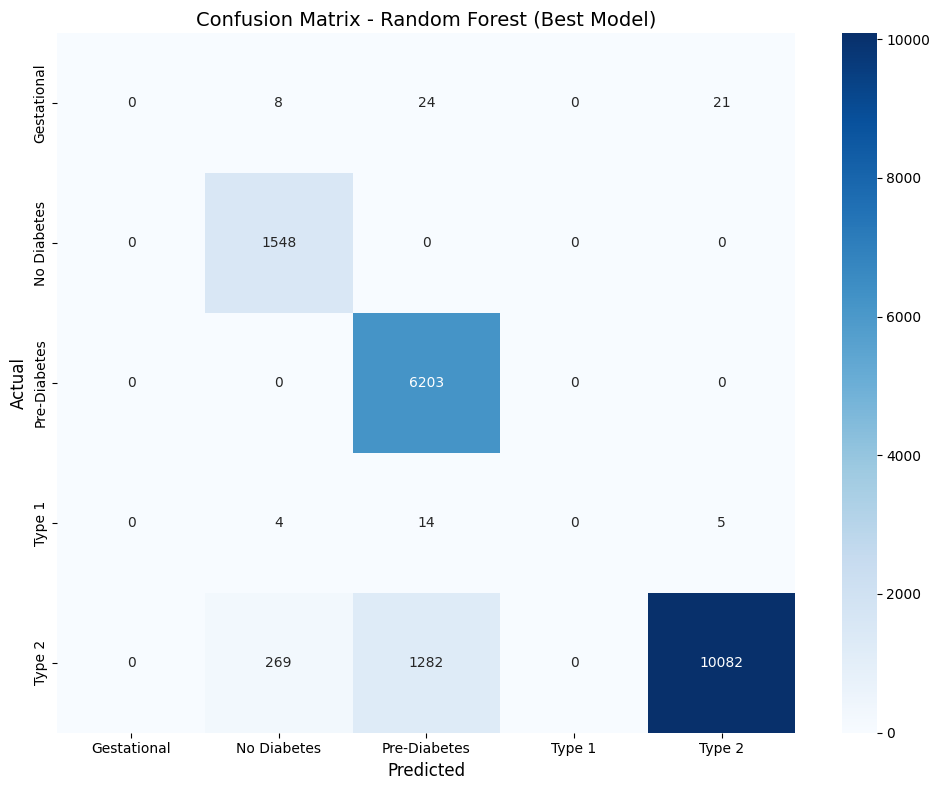

In [4]:
# Get confusion matrix from metrics
cm_rf = np.array(metrics['random_forest']['confusion_matrix'])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix - Random Forest (Best Model)', fontsize=14)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('../artifacts/confusion_matrix_rf.png', dpi=300, bbox_inches='tight')
plt.show()

Confusion Matrice of all three models

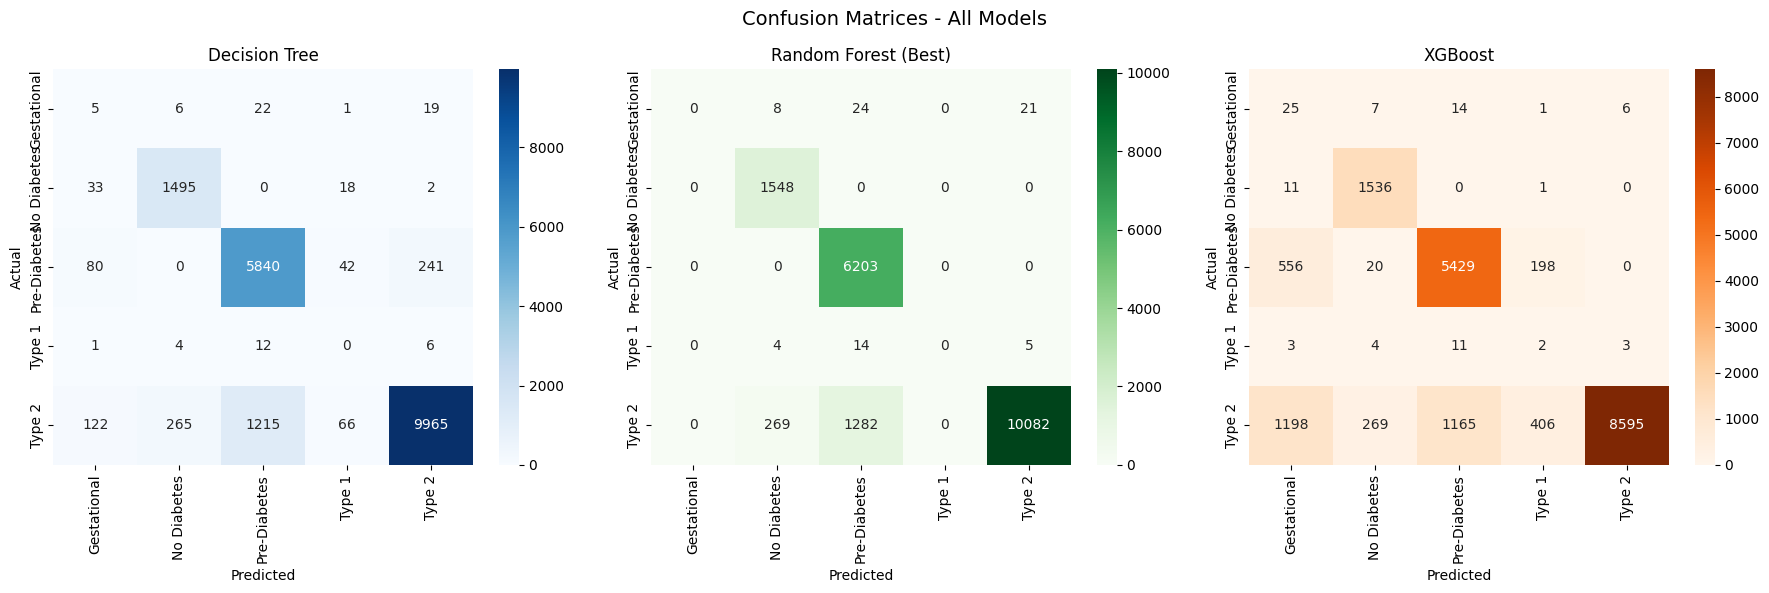

In [5]:
# Get confusion matrices for all models
cm_dt = np.array(metrics['decision_tree']['confusion_matrix'])
cm_rf = np.array(metrics['random_forest']['confusion_matrix'])
cm_xgb = np.array(metrics['xgboost']['confusion_matrix'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Decision Tree', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Random Forest (Best)', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# XGBoost
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=axes[2])
axes[2].set_title('XGBoost', fontsize=12)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', fontsize=14)
plt.tight_layout()
plt.savefig('../artifacts/confusion_matrices_all.png', dpi=300, bbox_inches='tight')
plt.show()

F1 Score Comparison per class

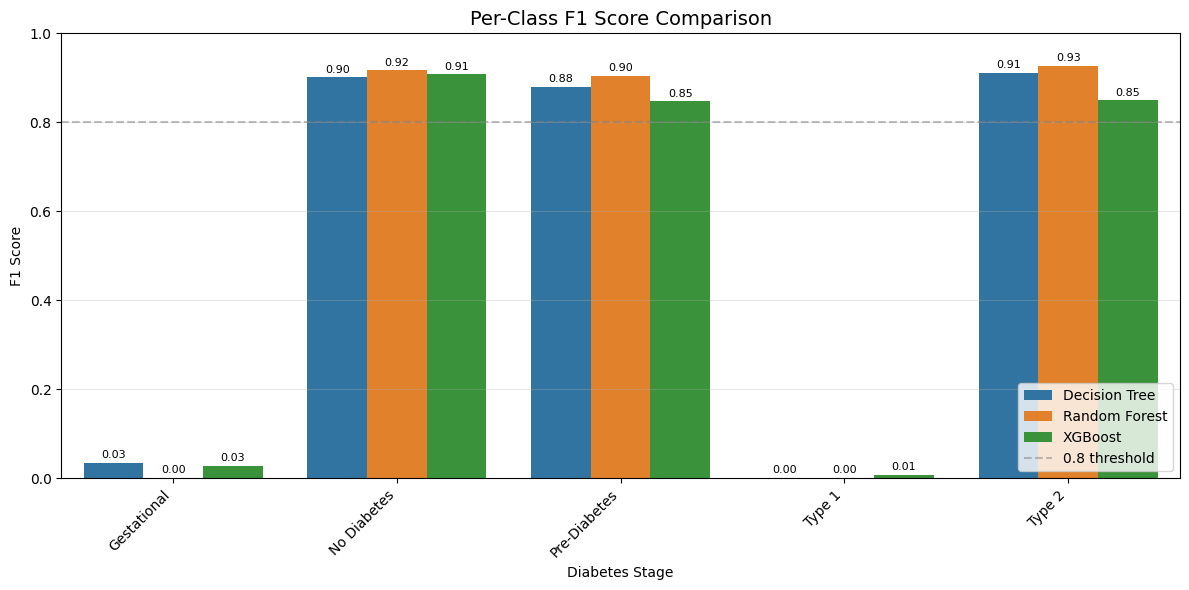

In [13]:
def f1_from_cm(cm):
    """Calculate per-class F1 score from confusion matrix"""
    f1_scores = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = sum(cm[:, i]) - tp
        fn = sum(cm[i, :]) - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)
    
    return f1_scores

# Calculate per-class F1 for each model
f1_dt = f1_from_cm(cm_dt)
f1_rf = f1_from_cm(cm_rf)
f1_xgb = f1_from_cm(cm_xgb)

# Create DataFrame
f1_df = pd.DataFrame({
    'Diabetes Stage': class_names,
    'Decision Tree': f1_dt,
    'Random Forest': f1_rf,
    'XGBoost': f1_xgb
})

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
f1_df_melted = f1_df.melt(id_vars=['Diabetes Stage'], var_name='Model', value_name='F1 Score')
sns.barplot(data=f1_df_melted, x='Diabetes Stage', y='F1 Score', hue='Model', ax=ax)
ax.set_title('Per-Class F1 Score Comparison', fontsize=14)
ax.set_ylim(0, 1.0)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('../artifacts/per_class_f1.png', dpi=300, bbox_inches='tight')
plt.show()

K-Means Cluster Sizes

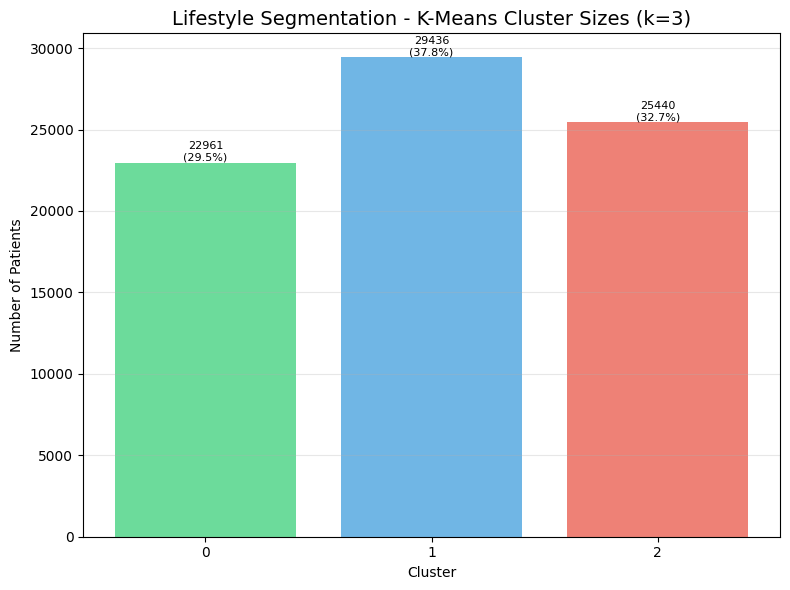

In [7]:
cluster_sizes = metrics['kmeans']['train_cluster_sizes']

fig, ax = plt.subplots(figsize=(8, 6))
clusters = list(cluster_sizes.keys())
sizes = list(cluster_sizes.values())
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(clusters, sizes, color=colors, alpha=0.7)
ax.set_title('Lifestyle Segmentation - K-Means Cluster Sizes (k=3)', fontsize=14)
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Patients')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{size}\n({size/sum(sizes)*100:.1f}%)', 
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../artifacts/kmeans_cluster_sizes.png', dpi=300, bbox_inches='tight')
plt.show()

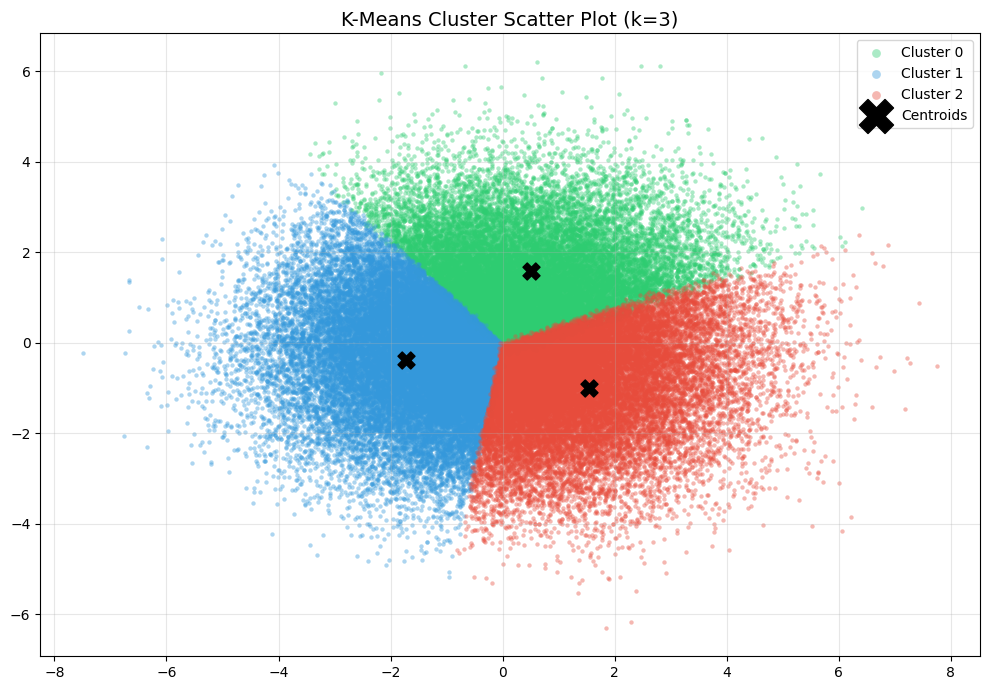

In [12]:
# Add cluster scatter plot:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load scaled training data and fit KMeans (k=3, matching the trained model)
X_train_scaled = pd.read_csv('../data/X_train_scaled.csv')
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_scaled)

# Reduce to 2D with PCA for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled.values)

# Cluster colours: 0=green, 1=blue, 2=red
color_map = {0: '#2ecc71', 1: '#3498db', 2: '#e74c3c'}
label_map = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

fig, ax = plt.subplots(figsize=(10, 7))
for cluster_id, color in color_map.items():
    mask = cluster_labels == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=label_map[cluster_id],
               alpha=0.4, s=10, linewidths=0)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', marker='X', s=150, zorder=5, label='Centroids')

ax.set_title('K-Means Cluster Scatter Plot (k=3)', fontsize=14)
ax.legend(markerscale=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/kmeans_cluster_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

Model Metrics Summary

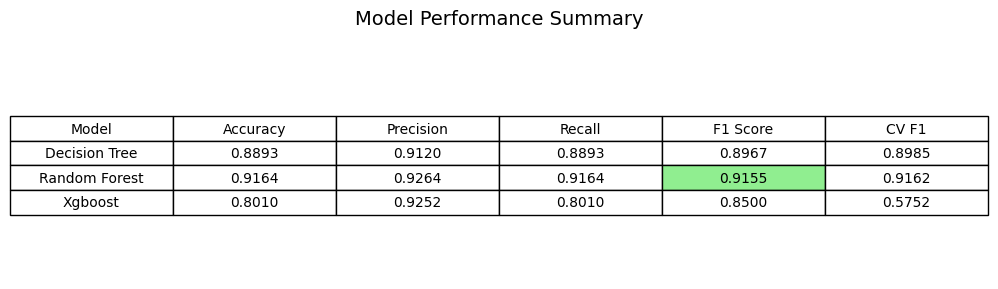

In [8]:
summary_data = []
for model in ['decision_tree', 'random_forest', 'xgboost']:
    summary_data.append({
        'Model': model.replace('_', ' ').title(),
        'Accuracy': f"{metrics[model]['accuracy']:.4f}",
        'Precision': f"{metrics[model]['precision_weighted']:.4f}",
        'Recall': f"{metrics[model]['recall_weighted']:.4f}",
        'F1 Score': f"{metrics[model]['f1_weighted']:.4f}",
        'CV F1': f"{metrics[model]['cv_f1_weighted']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)

# Plot as table
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Color best F1 score cell
best_f1_idx = summary_df['F1 Score'].astype(float).argmax()
table[(best_f1_idx + 1, 4)].set_facecolor('#90EE90')

ax.set_title('Model Performance Summary', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../artifacts/model_summary_table.png', dpi=300, bbox_inches='tight')
plt.show()